# SWAP-Stress: Source Data (units, conversions, distributions)

This notebook is an onboarding tour of the major **source datasets** used in SWAP-Stress.

Focus:
- What each source is (GSHP, NCSS, MT Mesonet, ReESH)
- Source units and our conversions to standardized columns: `suction_cm`, `theta`, `depth_cm`
- Where standardized/preprocessed files live on disk
- Quick distributions (histograms) and simple site maps

By design, this notebook **imports existing repo code** so it tracks the current project state.

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import seaborn as sns
except Exception:
    sns = None

try:
    import geopandas as gpd
except Exception:
    gpd = None

try:
    from IPython.display import display
except Exception:
    display = None

# -----------------------------
# Config
# -----------------------------
DATA_ROOT = os.environ.get(
    "SWAPSTRESS_DATA_ROOT",
    os.path.expanduser("~/data/IrrigationGIS/soils"),
)
DATA_ROOT = str(Path(DATA_ROOT).expanduser())

RESOLUTION_M = int(os.environ.get("SWAPSTRESS_RESOLUTION_M", "250"))
OUT_DIR = Path("notebooks/_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional heavier steps
RUN_TOY_STANDARDIZE = False  # reads raw source files if you point at them

print("DATA_ROOT:", DATA_ROOT)
print("RESOLUTION_M:", RESOLUTION_M)
print("OUT_DIR:", OUT_DIR.resolve())

DATA_ROOT: /home/dgketchum/data/IrrigationGIS/soils
RESOLUTION_M: 250
OUT_DIR: /home/dgketchum/code/swap-stress/notebooks/notebooks/_outputs


## 1) Data source registry

The registry is the canonical list of sources and how their on-disk paths are resolved.

In [2]:
from map.data.source_registry import SOURCES, DataPaths

rows = []
for name, src in SOURCES.items():
    paths = DataPaths(DATA_ROOT, src)
    rows.append(
        {
            "name": name,
            "description": src.description,
            "index_col": src.index_col,
            "has_vg_params": src.has_vg_params,
            "vg_source": src.vg_source,
            "preprocessed_dir": paths.preprocessed_dir,
            "fit_results_dir": paths.fit_results_dir,
            "ee_table": paths.ee_table,
            "labels_file": paths.labels_file,
        }
    )

src_df = pd.DataFrame(rows).sort_values("name").reset_index(drop=True)
src_df

,name,description,index_col,has_vg_params,vg_source,preprocessed_dir,fit_results_dir,ee_table,labels_file
0,gshp,Global Soil Hydraulic Properties - lab water r...,profile_id,True,labels_csv,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/swaps...,/home/dgketchum/data/IrrigationGIS/soils/soil_...
1,mt_mesonet,Montana Mesonet - field soil water potential s...,station,False,fitted_json,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/swaps...,None
2,ncss,National Cooperative Soil Survey - lab water r...,profile_id,False,fitted_json,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/swaps...,None
3,reesh,ReESH - Ameriflux ecosystem sites with soil WRC,site_id,False,fitted_json,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/swaps...,None
4,rosetta,Rosetta gridded pedotransfer predictions (7 de...,site_id,True,rosetta_join,None,None,/home/dgketchum/data/IrrigationGIS/soils/swaps...,None


## 2) Unit conversions and standard schema

Across sources we standardize to:
- `suction_cm`: suction head in **cm H₂O**
- `theta`: volumetric water content in **0–1 fraction**
- `depth_cm`: depth in **cm**

Conversions and filtering live in repo code, primarily:
- `retention_curve/standardize_swp.py`
- `utils/ncss.py`

In [3]:
from retention_curve import standardize_swp
from utils import ncss as ncss_utils

unit_table = pd.DataFrame(
    [
        {
            "source": "GSHP",
            "raw_suction_units": "m",
            "conversion_to_suction_cm": "abs(lab_head_m) * 100",
            "code_anchor": "retention_curve/standardize_swp.py::standardize_gshp",
        },
        {
            "source": "ReESH",
            "raw_suction_units": "MPa",
            "conversion_to_suction_cm": f"abs(MPa_Abs) * {standardize_swp.MPA_TO_CM}",
            "code_anchor": "retention_curve/standardize_swp.py::standardize_reesh",
        },
        {
            "source": "MT Mesonet",
            "raw_suction_units": "kPa",
            "conversion_to_suction_cm": "abs(KPA) * 10.19716",
            "code_anchor": "retention_curve/standardize_swp.py::standardize_mt_mesonet",
        },
        {
            "source": "NCSS",
            "raw_suction_units": "bar",
            "conversion_to_suction_cm": f"bar * {ncss_utils.BAR_TO_CM}",
            "code_anchor": "utils/ncss.py::ncss_to_standardized",
        },
    ]
)
unit_table

,source,raw_suction_units,conversion_to_suction_cm,code_anchor
0,GSHP,m,abs(lab_head_m) * 100,retention_curve/standardize_swp.py::standardiz...
1,ReESH,MPa,abs(MPa_Abs) * 10197.16,retention_curve/standardize_swp.py::standardiz...
2,MT Mesonet,kPa,abs(KPA) * 10.19716,retention_curve/standardize_swp.py::standardiz...
3,NCSS,bar,bar * 1019.72,utils/ncss.py::ncss_to_standardized


## 2b) Physical sanity filters (what gets dropped)

Standardization functions apply **physical bounds** to drop non-physical values.

These constants are part of the repo code and should be treated as the authoritative thresholds.

In [4]:
from retention_curve import standardize_swp
from utils import ncss as ncss_utils

filters = pd.DataFrame(
    [
        {
            "module": "retention_curve/standardize_swp.py",
            "SUCTION_CM_MAX": getattr(standardize_swp, "SUCTION_CM_MAX", None),
            "THETA_MIN": getattr(standardize_swp, "THETA_MIN", None),
            "THETA_MAX": getattr(standardize_swp, "THETA_MAX", None),
            "KPA_MAX": getattr(standardize_swp, "KPA_MAX", None),
            "BULK_DENSITY_MIN": getattr(standardize_swp, "BULK_DENSITY_MIN", None),
            "BULK_DENSITY_MAX": getattr(standardize_swp, "BULK_DENSITY_MAX", None),
        },
        {
            "module": "utils/ncss.py",
            "SUCTION_CM_MAX": getattr(ncss_utils, "SUCTION_CM_MAX", None),
            "THETA_MIN": getattr(ncss_utils, "THETA_MIN", None),
            "THETA_MAX": getattr(ncss_utils, "THETA_MAX", None),
            "KPA_MAX": None,
            "BULK_DENSITY_MIN": getattr(ncss_utils, "BULK_DENSITY_MIN", None),
            "BULK_DENSITY_MAX": getattr(ncss_utils, "BULK_DENSITY_MAX", None),
        },
    ]
)
filters

,module,SUCTION_CM_MAX,THETA_MIN,THETA_MAX,KPA_MAX,BULK_DENSITY_MIN,BULK_DENSITY_MAX
0,retention_curve/standardize_swp.py,1000000.0,0.0,1.0,200.0,0.5,2.5
1,utils/ncss.py,1000000.0,0.0,1.0,NaN,0.5,2.5


## 2c) Main processing steps (raw → standardized/preprocessed)

High-level pipeline per source:
1) Start from a raw source file (CSV/parquet) **outside the repo** under the `DATA_ROOT` data tree
2) Run a standardization helper that writes one standardized CSV per profile/station to:
   - `${DATA_ROOT}/soil_potential_obs/preprocessed/<source>/`
3) (Optional) Fit VG parameters from standardized CSVs (JSON outputs under `curve_fits/`)
4) Build a unified observation-level table by joining observations with EE features

Below we list the standardization entrypoints and the canonical preprocessed locations.

In [5]:
entrypoints = pd.DataFrame(
    [
        {
            "source": "gshp",
            "writer": "write_standardized_gshp(soil_csv_path, out_dir, minimum_points)",
        },
        {
            "source": "ncss",
            "writer": "write_standardized_ncss(parquet_path, out_dir, minimum_points)",
        },
        {
            "source": "mt_mesonet",
            "writer": "write_standardized_mt_mesonet(swp_csv_path, metadata_csv_path, out_dir, profile_key)",
        },
        {
            "source": "reesh",
            "writer": "write_standardized_reesh(in_dir, out_dir, profile_key)",
        },
    ]
)

paths_rows = []
for s in ["gshp", "ncss", "mt_mesonet", "reesh"]:
    src = SOURCES[s]
    paths = DataPaths(DATA_ROOT, src)
    paths_rows.append(
        {
            "source": s,
            "preprocessed_dir": paths.preprocessed_dir,
            "fit_results_dir": paths.fit_results_dir,
            "ee_table": paths.ee_table,
        }
    )

paths_df = pd.DataFrame(paths_rows)
if display is not None:
    display(entrypoints)
else:
    print(entrypoints)
paths_df

,source,writer
0,gshp,"write_standardized_gshp(soil_csv_path, out_dir..."
1,ncss,"write_standardized_ncss(parquet_path, out_dir,..."
2,mt_mesonet,"write_standardized_mt_mesonet(swp_csv_path, me..."
3,reesh,"write_standardized_reesh(in_dir, out_dir, prof..."


,source,preprocessed_dir,fit_results_dir,ee_table
0,gshp,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/swaps...
1,ncss,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/swaps...
2,mt_mesonet,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/swaps...
3,reesh,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/soil_...,/home/dgketchum/data/IrrigationGIS/soils/swaps...


## 3) Standardized / preprocessed files (inventory)

If you have the project data mounted under `DATA_ROOT`, standardized/preprocessed CSVs typically live in:

```
${DATA_ROOT}/soil_potential_obs/preprocessed/<source>/*.csv
```

The exact location is resolved by `map.data.source_registry.DataPaths`.

In [6]:
from glob import glob


def list_preprocessed_csvs(source_name: str, n: int = 10) -> list[str]:
    src = SOURCES[source_name]
    paths = DataPaths(DATA_ROOT, src)
    if not paths.preprocessed_dir:
        return []
    d = Path(paths.preprocessed_dir)
    if not d.exists():
        return []
    files = sorted(glob(str(d / "*.csv")))
    return files[:n]


for s in ["gshp", "ncss", "mt_mesonet", "reesh"]:
    files = list_preprocessed_csvs(s, n=5)
    print(f"{s}: {len(files)} example files")
    for f in files:
        print("  ", f)

gshp: 5 example files
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/gshp/10.csv
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/gshp/100.csv
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/gshp/101.csv
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/gshp/102.csv
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/gshp/103.csv
ncss: 5 example files
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/ncss/11851.csv
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/ncss/11852.csv
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/ncss/12641.csv
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/ncss/12644.csv
   /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/preprocessed/ncss/14308.csv
mt_mesonet: 5 example files
   /home/dgketchum/data/Irrig

## 4) Histograms of standardized variables

This loads a small sample of standardized CSVs (if present) and plots distributions for:
- `theta`
- `log10(suction_cm)`

In [7]:
def load_preprocessed_sample(
    source_name: str, max_files: int = 50, max_rows: int = 200_000
) -> pd.DataFrame:
    src = SOURCES[source_name]
    paths = DataPaths(DATA_ROOT, src)
    if not paths.preprocessed_dir:
        return pd.DataFrame()
    d = Path(paths.preprocessed_dir)
    if not d.exists():
        return pd.DataFrame()

    fps = sorted(d.glob("*.csv"))[:max_files]
    frames = []
    for fp in fps:
        try:
            frames.append(pd.read_csv(fp))
        except Exception:
            continue
    if not frames:
        return pd.DataFrame()
    df = pd.concat(frames, ignore_index=True)
    # harmonize column names (gshp uses 'suction'/'depth', others use '_cm' suffix)
    if "suction" in df.columns and "suction_cm" not in df.columns:
        df = df.rename(columns={"suction": "suction_cm"})
    if "depth" in df.columns and "depth_cm" not in df.columns:
        df = df.rename(columns={"depth": "depth_cm"})
    df["source"] = source_name
    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=7)
    return df


samples = []
for s in ["gshp", "ncss", "mt_mesonet", "reesh"]:
    d = load_preprocessed_sample(s)
    print(s, len(d))
    if not d.empty:
        samples.append(d)

df_all = pd.concat(samples, ignore_index=True) if samples else pd.DataFrame()
df_all.head()

gshp 1561
ncss 814
mt_mesonet 20040
reesh 12335


,suction_cm,theta,depth_cm,SWCC_classes,sand_tot_psa,silt_tot_psa,clay_tot_psa,db_od,climate_classes,source,source_db,name,profile_id,station,Sample_ID,Site,Plot
0,1000.0,0.3,15.5,YWYD,NaN,NaN,NaN,0.2,Boreal,gshp,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000.0,0.3,15.5,YWYD,NaN,NaN,NaN,0.2,Boreal,gshp,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000.0,0.3,15.5,YWYD,NaN,NaN,NaN,0.2,Boreal,gshp,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000.0,0.3,15.5,YWYD,NaN,NaN,NaN,0.2,Boreal,gshp,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000.0,0.3,15.5,YWYD,NaN,NaN,NaN,0.2,Boreal,gshp,NaN,NaN,NaN,NaN,NaN,NaN,NaN


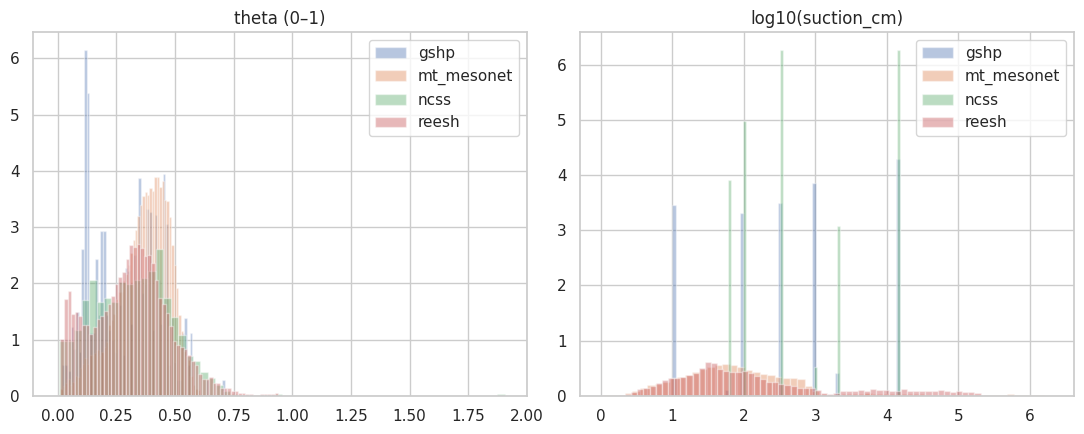

Saved: notebooks/_outputs/source_data_histograms.png


In [8]:
if df_all.empty:
    print(
        "No preprocessed files found under DATA_ROOT. Set SWAPSTRESS_DATA_ROOT or mount project data."
    )
else:
    dfp = df_all.copy()
    for col in ["theta", "suction_cm"]:
        if col in dfp.columns:
            dfp[col] = pd.to_numeric(dfp[col], errors="coerce")
    if "suction_cm" in dfp.columns:
        dfp = dfp[dfp["suction_cm"].notna() & (dfp["suction_cm"] > 0)]
        dfp["log10_suction_cm"] = np.log10(dfp["suction_cm"].clip(lower=1e-6))

    if sns is not None:
        sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    plots = [
        ("theta", "theta (0–1)"),
        ("log10_suction_cm", "log10(suction_cm)"),
    ]

    for ax, (col, label) in zip(axes, plots):
        if col not in dfp.columns:
            ax.axis("off")
            ax.set_title(f"Missing: {col}")
            continue
        for src, g in dfp.groupby("source"):
            vals = g[col].dropna().values
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=60, alpha=0.4, density=True, label=src)
        ax.set_title(label)
        ax.legend()

    fig.tight_layout()
    out = OUT_DIR / "source_data_histograms.png"
    fig.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

## 5) Simple maps of site locations

This attempts to load site/station shapefiles from the standard project layout under `DATA_ROOT`.

If `geopandas` is not available or the shapefiles are not present, this section will safely skip.

reesh_shp: /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/reesh/shapefile/reesh_sites_mgrs.shp
mesonet_shp: /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/mt_mesonet/station_metadata_clean_mgrs.shp
gshp_shp: /home/dgketchum/data/IrrigationGIS/soils/soil_potential_obs/gshp/wrc_aggregated_mgrs.shp
Loaded world boundaries: 251 features
Loaded US state boundaries: 56 features


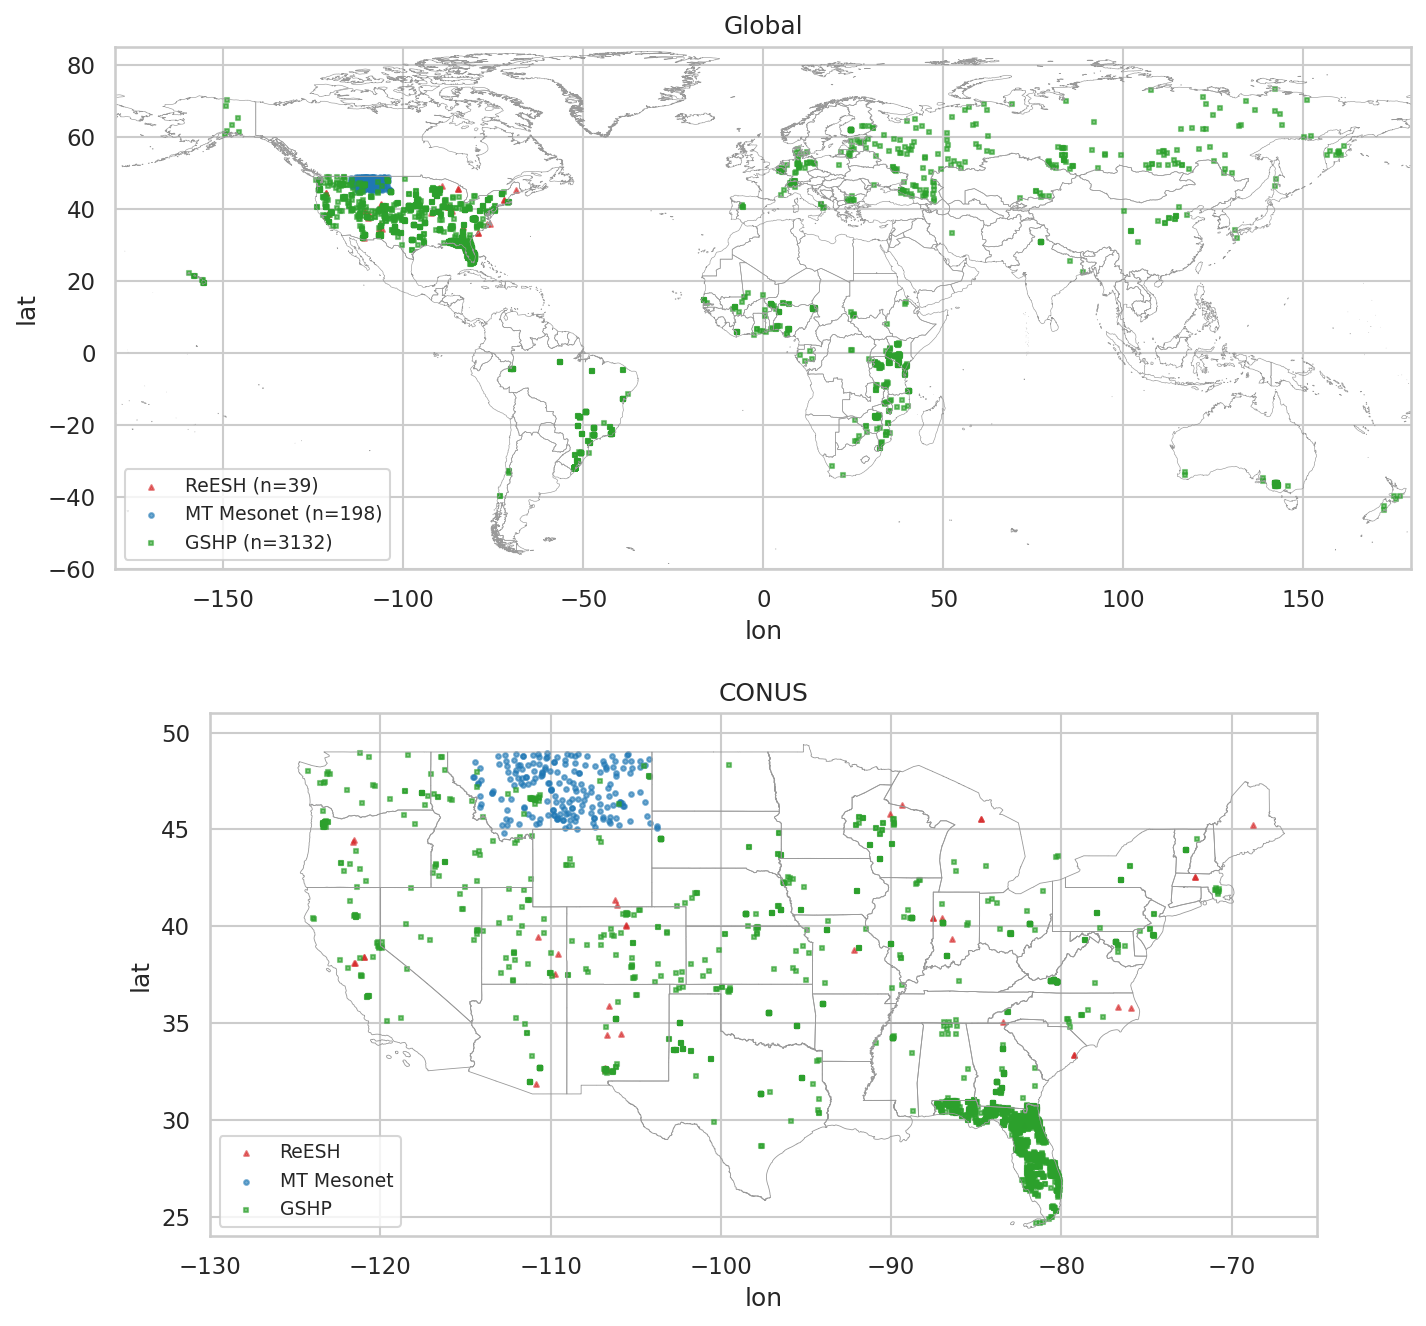

Saved: notebooks/_outputs/source_site_maps.png


In [9]:
BOUNDARIES_ROOT = os.path.expanduser("~/data/IrrigationGIS/boundaries")
WORLD_SHP = os.path.join(BOUNDARIES_ROOT, "world_countries", "World_Countries_shp.shp")
US_STATES_SHP = os.path.join(BOUNDARIES_ROOT, "us_states_tiger_wgs.shp")


def _first_existing(*paths: str) -> str | None:
    for p in paths:
        if p and Path(p).exists():
            return p
    return None


reesh_shp = _first_existing(
    f"{DATA_ROOT}/soil_potential_obs/reesh/shapefile/reesh_sites_mgrs.shp",
    f"{DATA_ROOT}/soil_potential_obs/reesh/shapefile/reesh_sites_mgrs_5070.shp",
)
mesonet_shp = _first_existing(
    f"{DATA_ROOT}/soil_potential_obs/mt_mesonet/station_metadata_clean_mgrs.shp",
    f"{DATA_ROOT}/soil_potential_obs/mt_mesonet/station_metadata_clean_mgrs_5070.shp",
)
gshp_shp = _first_existing(
    f"{DATA_ROOT}/soil_potential_obs/gshp/wrc_aggregated_mgrs.shp",
    f"{DATA_ROOT}/soil_potential_obs/gshp/wrc_aggregated_mgrs_5070.shp",
)

print("reesh_shp:", reesh_shp)
print("mesonet_shp:", mesonet_shp)
print("gshp_shp:", gshp_shp)

if gpd is None:
    print("geopandas not available; skipping mapping")
else:
    # load boundary outlines
    world = None
    if Path(WORLD_SHP).exists():
        world = gpd.read_file(WORLD_SHP).to_crs(4326)
        print(f"Loaded world boundaries: {len(world)} features")

    us_states = None
    if Path(US_STATES_SHP).exists():
        us_states = gpd.read_file(US_STATES_SHP).to_crs(4326)
        print(f"Loaded US state boundaries: {len(us_states)} features")

    layers = []
    if reesh_shp:
        reesh = gpd.read_file(reesh_shp)
        reesh = reesh.to_crs(4326) if reesh.crs else reesh.set_crs(4326)
        layers.append(("ReESH", reesh, "^", "#d62728"))
    if mesonet_shp:
        mesonet = gpd.read_file(mesonet_shp)
        mesonet = mesonet.to_crs(4326) if mesonet.crs else mesonet.set_crs(4326)
        layers.append(("MT Mesonet", mesonet, "o", "#1f77b4"))
    if gshp_shp:
        gshp = gpd.read_file(gshp_shp)
        gshp = gshp.to_crs(4326) if gshp.crs else gshp.set_crs(4326)
        layers.append(("GSHP", gshp, "s", "#2ca02c"))

    if not layers:
        print("No shapefiles found; skipping mapping")
    else:
        fig, (ax_g, ax_c) = plt.subplots(2, 1, figsize=(11, 9), dpi=150)

        # Global
        ax_g.set_title("Global")
        ax_g.set_xlim(-180, 180)
        ax_g.set_ylim(-60, 85)
        ax_g.set_xlabel("lon")
        ax_g.set_ylabel("lat")
        if world is not None:
            world.boundary.plot(ax=ax_g, color="0.6", linewidth=0.3)

        # CONUS
        ax_c.set_title("CONUS")
        ax_c.set_xlim(-130, -65)
        ax_c.set_ylim(24, 51)
        ax_c.set_xlabel("lon")
        ax_c.set_ylabel("lat")
        if us_states is not None:
            us_states.boundary.plot(ax=ax_c, color="0.6", linewidth=0.4)

        for name, gdf, marker, color in layers:
            try:
                xs = gdf.geometry.x
                ys = gdf.geometry.y
            except Exception:
                continue
            ax_g.scatter(
                xs,
                ys,
                s=5,
                marker=marker,
                color=color,
                alpha=0.6,
                label=f"{name} (n={len(gdf)})",
            )
            ax_c.scatter(xs, ys, s=5, marker=marker, color=color, alpha=0.6, label=name)

        ax_g.legend(loc="lower left", fontsize=9)
        ax_c.legend(loc="lower left", fontsize=9)
        fig.tight_layout(h_pad=1.5)
        out = OUT_DIR / "source_site_maps.png"
        fig.savefig(out, dpi=200)
        plt.show()
        print("Saved:", out)